In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="5" color="red"><b>ch2.
군집분석 </b></
# 1절 . 군집모델 클러스터링
- 클러스터 (cluster) : 독립변수의 특성이 유사한 데이터의 그룹
- 클러스터링 (clustering) : 주어진 데이터를 여러 개의 클러스터로 구분하는 것
1)중심 기반 클러스터링 (K Means) : https://commons.wikimedia.org/wiki/File:KMeans-Gaussian-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/e/e5/KMeans-Gaussian-data.svg"
 style="display: block; margin-left: 0; width: 20%;">
2)연결기반 클러스터링 (DBSCAN) : https://commons.wikimedia.org/wiki/File:DBSCAN-density-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/0/05/DBSCAN-density-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">
3)밀도기반 클러스터링 (DBSCAN 의 변형으로 OPTICS) :
https://commons.wikimedia.org/wiki/File:OPTICS Gaussian data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/8/8a/OPTICS-Gaussian-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">

# 2절.. K Means 클러스터링
- 가장 단순하고 빠른 클러스터링 알고리즘의 하나
- 목적함수값이 최소화될 때까지 클러스터의 중심 (centroid) 𝜇k 와 각 데이터가소속될 클러스터를 반복해서 찾는 것
- K-Means 클러스터링의 세부 알고리즘
    * 1.임의의 중심값 μk 를 고릅니다 보통 데이터 샘플 중의 하나를 선택합니다
    * 2.중심에서 각 샘플 데이터까지의 거리를 계산합니다
    * 3.각 데이터 샘플에서 가장 가까운 중심을 선택하여 클러스터 갱신합니다
    * 4.다시 만들어진 클러스터에 대해 중심을 다시 계산하고 1~4 를 반복합니다

In [7]:
import matplotlib.pyplot as plt
plt.rcParams['font.family']="Malgun Gothic"
plt.rcParams

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'both',
   

In [8]:
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=20,# 데이터갯수(기본값100) : 20행
                          n_features=2, # 독립변수 갯수(기본값20)
                          n_informative=2, # 독립변수중 종속변수에 영향을 주는 독립변수 갯수(기본값2)
                          n_redundant=0, # 종속변수에 영향을 안 미치는 독립변수 갯수(기본값2)
                          n_classes=2,   # 종속변수의 클래스 수(0,1)
                          n_clusters_per_class=1, # 각 클래스 당 군의 갯수(서브 그룹이 없음)
                          random_state=123
                         )
X.shape,y.shape

((20, 2), (20,))

In [9]:
# 5:5로 분류되었는지 확인
import numpy as np
value, count = np.unique(y, return_counts=True)
{v:c for v, c in zip(value, count)}

{0: 10, 1: 10}

In [10]:
np.column_stack([X, y])[:3] # np.c_[X, y]

array([[ 1.03859554,  2.51175389,  0.        ],
       [ 1.00271366,  1.93521549,  0.        ],
       [-1.6881048 ,  0.02599427,  1.        ]])

C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


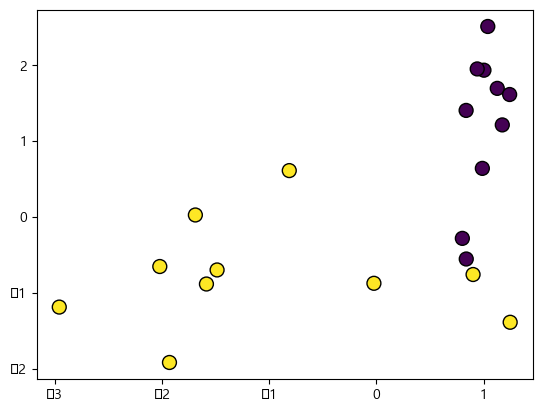

In [11]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=100, edgecolors='k')
plt.show()

In [12]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # 군의 갯수
              init='k-means++', # 초기중심점이 서로 멀리 떨어지도록 똑똑하게 초기화/'random'
              max_iter=300, # 각 실행에서 최대 300번 중심점 이동(중심점이 이동되지 않으면 300까지 안 해)
              n_init='auto'
              )
model.fit(X)

KMeans(n_clusters=2, n_init='auto')

In [13]:
c0, c1 = model.cluster_centers_ # 모델이 선정한 두 클러스터의 중심점
c0, c1

(array([1.01138251, 0.83200493]), array([-1.56258716, -0.69768199]))

In [14]:
print('실제값 :', y)
pred = model.predict(X)
print('예측값 :', pred)
labels = model.labels_
print('라 벨  :', labels)

실제값 : [0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0]
예측값 : [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]
라 벨  : [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]


In [15]:
# 0그룹으로 라벨링
X[labels==0]

array([[ 1.03859554,  2.51175389],
       [ 1.00271366,  1.93521549],
       [ 0.90134424, -0.75896558],
       [ 0.83653082,  1.40488232],
       [ 0.83780453, -0.554389  ],
       [ 1.12694685,  1.69570061],
       [ 0.80138648, -0.28232585],
       [ 0.9399586 ,  1.9518949 ],
       [ 1.24232232,  1.6146173 ],
       [ 1.24732102, -1.38872822],
       [ 0.98786201,  0.64060416],
       [ 1.17380403,  1.21379918]])

C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


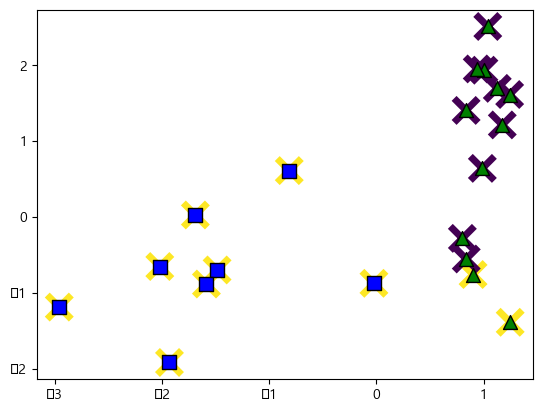

In [16]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=300, marker='x', linewidths=5)
plt.scatter(X[labels==0, 0], X[labels==0, 1], marker='^', c='g', edgecolors='k', s=100)
plt.scatter(X[labels==1, 0], X[labels==1, 1], marker='s', c='b', edgecolors='k', s=100)
plt.scatter(c0[0], X[labels==0, 1], marker='^', c='g', edgecolors='k', s=100)
plt.scatter(X[labels==1, 0], X[labels==1, 1], marker='s', c='b', edgecolors='k', s=100)

In [18]:
# X데이터를 Normalizer를 이용한 반환
import pandas as pd
from sklearn.preprocessing import Normalizer
scaler = Normalizer()
Xnor = scaler.fit_transform(X)
pd.concat([pd.DataFrame(X,columns=['x0','x1']),
         pd.DataFrame(Xnor,columns=['x0_nor','x1_nor'])],
         axis=1)

,x0,x1,x0_nor,x1_nor
0,1.038596,2.511754,0.382116,0.924114
1,1.002714,1.935215,0.460053,0.887892
2,-1.688105,0.025994,-0.999881,0.015397
3,0.901344,-0.758966,0.764937,-0.644105
4,0.836531,1.404882,0.511615,0.859215
5,-0.023176,-0.874812,-0.026484,-0.999649
6,0.837805,-0.554389,0.833951,-0.551839
7,-1.929572,-1.918940,-0.709057,-0.705151
8,-0.812496,0.611408,-0.799038,0.601281
9,1.126947,1.695701,0.553503,0.832847


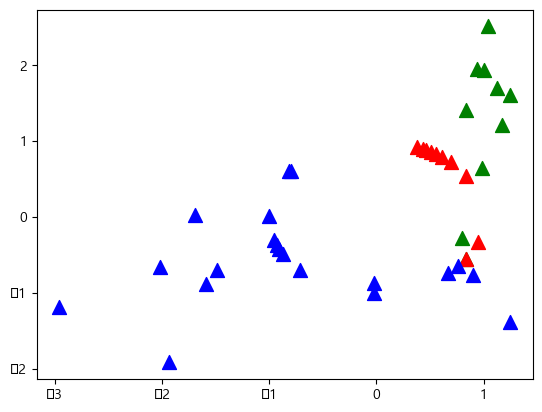

In [20]:
plt.scatter(X[y==0,0],X[y==0,1],s=100,marker='^',c='g')
plt.scatter(X[y==1,0],X[y==1,1],s=100,marker='^',c='b')
plt.scatter(Xnor[y==0,0],Xnor[y==0,1],s=100,marker='^',c='r')
plt.scatter(Xnor[y==1,0],Xnor[y==1,1],s=100,marker='^',c='b')

### K-means 클러스터링의 한계(pdf 13p)
- 군의 특성이 다를 경우
    * 크기(Sizes)
      밀도(Densities)
      비구형 (Non globular shapes)
### 군의 크기가 다를경우

In [23]:
# np.random.normal(평균,표준편차,size)
group0 = np.random.normal(-10,2,(10,2))
y0 = np.full(group0.shape[0],0)
group0 = np.c_[group0,y0]
group0[:3]

array([[-10.26982344,  -7.86220065,   0.        ],
       [-13.33457957,  -5.46813663,   0.        ],
       [-10.91982388,  -9.04792358,   0.        ]])

In [24]:
# group1 : 평균10, 표준편차 2인 10행 2열 데이터
group1 = np.random.normal(-10,2,(10,2))
y1 = np.full(group0.shape[0],1)
group1 = np.c_[group1,y1]
group1[:3]

array([[-10.58333833,  -8.71601117,   1.        ],
       [ -8.68061509, -10.32097976,   1.        ],
       [-10.24062182, -10.69206277,   1.        ]])

In [25]:
# group2 : 평균0, 표준편차 5인 100행 2열 데이터
group2 = np.random.normal(0,5,(100,2))
y2 = np.full(group2.shape[0],2)
group2 = np.c_[group2,y2]
group2[:3]

array([[-1.93225926,  3.55779156,  2.        ],
       [ 0.86646399, -5.83159516,  2.        ],
       [-4.17995168, -6.26353289,  2.        ]])

In [28]:
data = np.r_[group0,group1,group2] # 120행 3열
data[::10]

array([[-10.26982344,  -7.86220065,   0.        ],
       [-10.58333833,  -8.71601117,   1.        ],
       [ -1.93225926,   3.55779156,   2.        ],
       [  3.18942154,   1.98897314,   2.        ],
       [  5.40749175,  -0.50683147,   2.        ],
       [  5.0544358 ,  -4.52441346,   2.        ],
       [  7.90978808,   3.17875237,   2.        ],
       [  6.18049189,   3.48050016,   2.        ],
       [ -0.93854268,  -3.57781758,   2.        ],
       [  3.01359732,  10.87891128,   2.        ],
       [  3.63119579,  -3.01734683,   2.        ],
       [ -1.40504068,  -1.90745746,   2.        ]])

In [29]:
group1.shape, group0.shape, group2.shape, data.shape

((10, 3), (10, 3), (100, 3), (120, 3))

C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


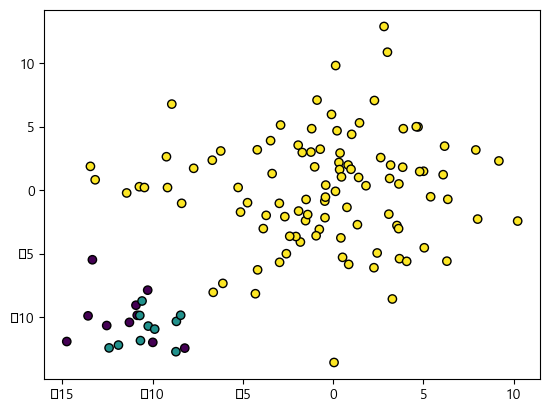

In [32]:
plt.scatter(data[:,0],data[:,1],c=data[:,2], edgecolors='k')

In [33]:
# 3개 그룹으로 클러스터링
model = KMeans(n_clusters=3, n_init=5)
model.fit(data[:, :2])


KMeans(n_clusters=3, n_init=5)

In [37]:
labels = model.labels_ # 모델이 구분한 군들
labels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 2, 1,
       1, 1, 0, 2, 1, 1, 1, 1, 1, 0, 2, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 2, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1])

In [39]:
centers = model.cluster_centers_ # 군의 중심점

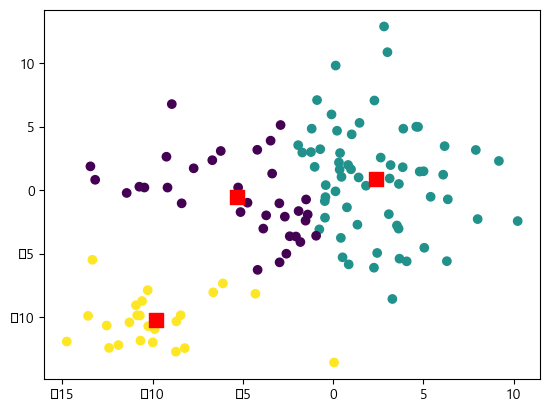

In [41]:
plt.scatter(data[:,0],data[:,1],c=labels)
plt.scatter(centers[:,0],centers[:,1],c='r',s=100,marker='s')
plt.show()

In [ ]:
# 6개 그룹으로 클러스터링
model = KMean(n_clusters=6,n_init=5)
model.fit(data)

In [ ]:
plt.scatter(data[:0],data[:,1],c=labels)

# 3절 Hierachical클러스터링(계층적 군집)
- 비슷한 군끼리 묶으면서 하나의 군집이 될 때까지 군을 묶는 알고리즘
- 군집간의 거리를 기반으로 클러스터링을 하는 알고리즘
- 군집의 수를 미리 정해주지 않아도 됨
- dendrogram 이라는 그래프를 이용하면 손쉽게 시각화

In [43]:
from seaborn import load_dataset
iris = load_dataset('iris')
iris.sample()

,sepal_length,sepal_width,petal_length,petal_width,species
140,6.7,3.1,5.6,2.4,virginica


In [45]:
# 계층적 군집화를 위해 라벨 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris['species'] = le.fit_transform(iris['species'])
iris.iloc[::50]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
50,7.0,3.2,4.7,1.4,1
100,6.3,3.3,6.0,2.5,2


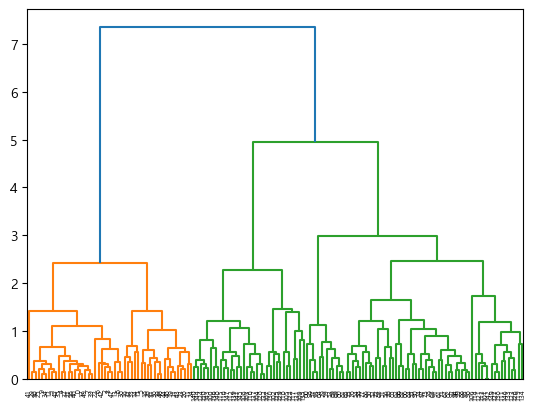

In [48]:
from scipy.cluster.hierarchy import linkage, dendrogram
# method : 각 클러스터 간 거리를 어떻게 계산할지
cluster_model = linkage(iris, method='complete') # 두 클러스터에서 가장 먼 거리를 이용해서 측정
dendrogram(cluster_model, labels=iris.index)

plt.savefig('data/ch2_dendrogram.png',dpi=300,bbox_inches='tight')
plt.show()

In [52]:
# 클러스터 생성하는 함수
from scipy.cluster.hierarchy import fcluster
fcluster(cluster_model, #linkage()로 만든 클러스터링결과(모델)
         6, # 클러스터를 나누는 임계값
         criterion='distance')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [53]:
from scipy.cluster.hierarchy import fcluster
fcluster(cluster_model, #linkage()로 만든 클러스터링결과(모델)
         4, # 클러스터를 나누는 임계값
         criterion='distance')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [54]:
fcluster(cluster_model, #linkage()로 만든 클러스터링결과(모델)
         2, # 클러스터를 나누는 임계값
         criterion='distance')

array([1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2,
       1, 2, 2, 1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2,
       2, 1, 2, 1, 2, 1, 6, 6, 6, 5, 6, 6, 6, 5, 6, 5, 5, 6, 6, 6, 5, 6,
       6, 6, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 6, 6, 6, 6, 6, 6,
       6, 5, 6, 6, 6, 5, 6, 6, 6, 6, 5, 6, 3, 7, 4, 3, 3, 4, 7, 4, 3, 4,
       3, 7, 3, 7, 7, 3, 3, 4, 4, 7, 3, 7, 4, 7, 3, 4, 7, 7, 3, 4, 4, 4,
       3, 7, 7, 4, 3, 3, 7, 3, 3, 3, 7, 3, 3, 3, 7, 3, 3, 7], dtype=int32)

In [55]:
fcluster(cluster_model,
         2, # 클러스터의 갯수
         criterion='maxclust')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [56]:
pred = fcluster(cluster_model, 4, criterion='distance')
pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [58]:
np.choose([3,3,1,1,2,2],[0,1,2,0])

array([0, 0, 1, 1, 2, 2])

In [59]:
adjusted_pred = np.choose(pred,[9,0,2,1])
adjusted_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 1, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1])

In [60]:
pred_name = le.inverse_transform(adjusted_pred)
original_name = le.inverse_transform(iris['species'])
pd.crosstab(original_name, pred_name, 
            rownames=['실제값'],colnames=['예측값'],
            margins=True)

예측값,setosa,versicolor,virginica,All
실제값,,,,
setosa,50,0,0,50
versicolor,0,50,0,50
virginica,0,16,34,50
All,50,66,34,150


<Axes: xlabel='petal_length', ylabel='petal_width'>

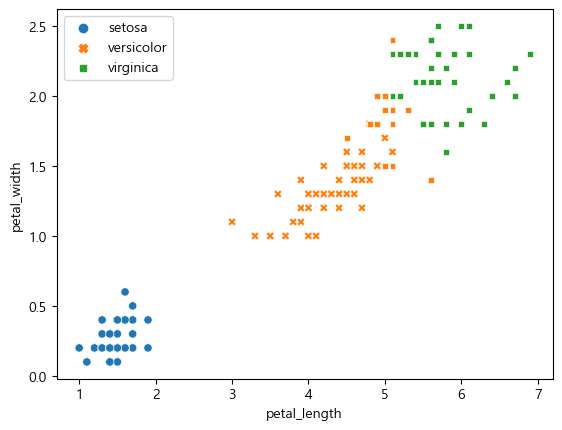

In [62]:
import seaborn as sns
sns.scatterplot(data=iris,
               x='petal_length',
               y='petal_width',
               hue = pred_name,
               style = original_name)

# 4절. DBSCAN 클러스터링
    - 연결기반(밀도기반) 군집화 알고리즘(클러스트 수를 미리 정할 필요없음. 이상차를 자동감지)
    - 단점 : 클러스트의 밀도가 일정하지 않으면 성능 떨어짐
    - eps(반경)과 min_samples(최소샘플수)를 적절히 조절하여 군집화

array([[ 2.3796962 ,  0.45578033,  0.        ],
       [ 0.6679311 ,  0.70463976,  0.        ],
       [ 3.8796962 , -0.97426048,  1.        ],
       [ 2.1679311 , -0.47699863,  1.        ]])

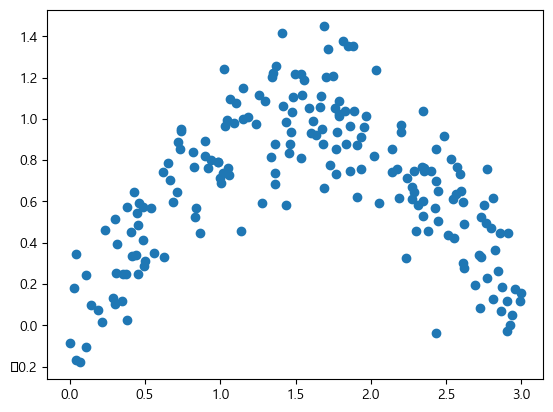

In [73]:
import numpy as np
X1 = np.random.rand(200)*3 # rand(n) : 0<=x<1의 균등포 난수 nro
noise = np.random.normal(0,0.2,X1.shape)
Y1 = np.sin(X1) + noise
plt.scatter(X1,Y1)
group1 = np.c_[X1,Y1, np.zeros(X1.shape[0])]

X2 = X1+1.5
nosie = np.random.normal(0,0.2,X1.shape)
Y2 = np.cos(X2)+noise
group2 = np.c_[X2,Y2, np.ones(X2.shape[0])]

data = np.r_[group1,group2]
data[::100]

C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


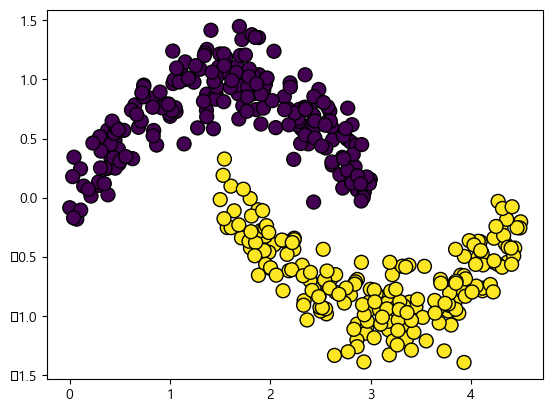

In [74]:
plt.scatter(data[:,0],data[:,1],c=data[:,2],s=100,edgecolors='k')
plt.show()

In [82]:
model = KMeans(n_clusters=7,n_init=5)
model.fit(data[:,:2])
# labels=model.labels_
# centers = 

KMeans(n_clusters=7, n_init=5)

In [77]:
labels=model.labels_
centers = model.cluster_centers_

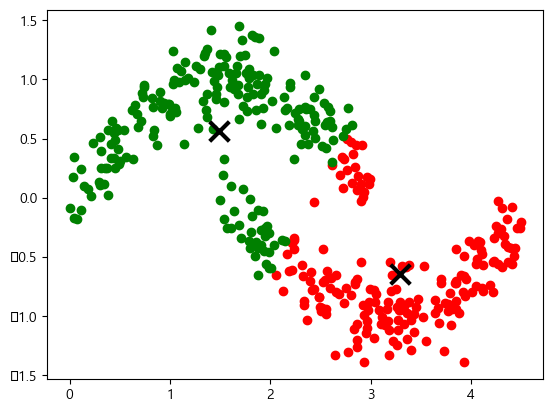

In [84]:
data[labels==1]
colors = ['r','g','b','c','m','k','y']
for i,c in enumerate(centers):
    plt.scatter(data[labels==i,0],
               data[labels==i,1],
               c=colors[i])
    plt.scatter(c[0],c[1],c='k',marker='x',s=200,lw=3)

In [85]:
from sklearn.cluster import DBSCAN
db_model = DBSCAN(eps=0.3,min_samples=10)
db_model.fit(data[:,:2])

DBSCAN(eps=0.3, min_samples=10)

In [92]:
labels = db_model.labels_
# print(labels)# -1은 이상치
n_cluster = len(set(labels))-(1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f'이상치를 제외한 label수 : {n_cluster},이상치 갯수:{n_noise}')

이상치를 제외한 label수 : 2,이상치 갯수:2


C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


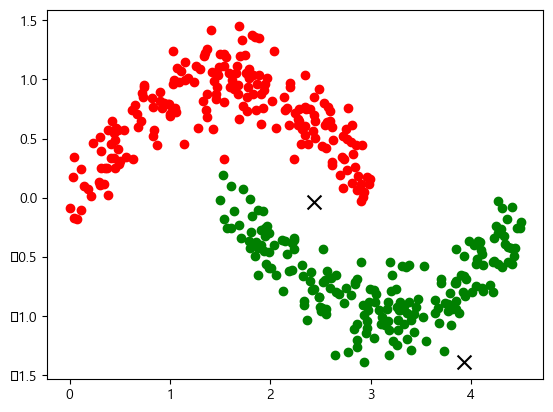

In [96]:
colors = ['r','g']
markers = ['^','s']
for i in range(n_cluster):
    plt.scatter(data[labels==i,0],
               data[labels==i,1],
               c=colors[i])
plt.scatter(data[labels==-1,0],
           data[labels==-1,1],
           c='k',
           marker='x',
           s=100)

# 5절. 군집모형 성능평가
- 예측 모형의 score(분류, 회귀)
    * score 메소드를 통해서 예측 모형의 정확도를 평가
- metrics 패키지
    * 분류분석 recall, precision을 평가하는 함수
    * **군집 모형등의 평가를 위한 함수**
- scoring 매개변수
    - GridSearchCV클래스 ->4장

In [115]:
from seaborn import load_dataset
iris = load_dataset('iris')
iris_X = iris.iloc[:,:-1]
iris_y = iris.iloc[:,-1]

In [101]:
from sklearn.cluster import KMeans
iris_3cluster_model = KMeans(n_clusters=3, random_state=1, n_init=10)
iris_3cluster_model.fit(iris_X)

KMeans(n_clusters=3, n_init=10, random_state=1)

In [102]:
# pred3 = iris_3cluster_model.labels_
pred3 = iris_3cluster_model.predict(iris_X)
pred3

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0])

In [105]:
pred3_str = np.choose(pred3,['versicolor','setosa','virginica']) # 모델이 군집화한 데이터
# 군집분석의 성능 평가함수르르 쓰기위해서 pred3_str(넘파이 배열)과 iris_y(시리즈)

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object

In [119]:
# iris_y를 라벨인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris_y3 = le.fit_transform(iris_y)
pred3 = np.choose(pred3,[1,0,2])
# 군집분석의 성능 평가 함수를 쓰기위해 pred3과 iris_y3(둘다 넘파이 배열)

In [108]:
from sklearn.preprocessing import LabelEncoder
iris_2cluster_model = KMeans(n_clusters=2, random_state=1, n_init=10)
iris_2cluster_model.fit(iris_X)

KMeans(n_clusters=2, n_init=10, random_state=1)

In [109]:
# pred2 = iris_2cluster_model.labels_
pred2 = iris_2cluster_model.predict(iris_X)
pred2

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [111]:
iris_y2 = np.array([0]*50 + [1]*100)
# 군집분석의 성능 평가 함수를 쓰기위해 pred2와 iris_y2(둘다 넘파이 배열)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [114]:
pred2_str = np.choose(pred2,['setosa','그외'])
iris_y2_str = np.choose(iris_y2,['setosa','그외'])
# 군집분석의 성능평가 함수를 쓰기위해 pred2_str과 iris_y2_str(둘다 넘파이 배열)

In [117]:
pd.crosstab(iris_y2_str,pred2_str)

col_0,setosa,그외
row_0,,
setosa,50,0
그외,3,97


In [121]:
pred3_str.shape, iris_y.shape,pred3.shape,iris_y3.shape #3개 클러스터

((150,), (150,), (150,), (150,))

In [122]:
pred2_str.shape, iris_y2.shape,pred2.shape,iris_y2.shape # 2개 클러스터

((150,), (150,), (150,), (150,))

In [130]:
from sklearn.metrics import adjusted_rand_score
adjusted_rand_score(labels_true=iris_y,
                   labels_pred=pred3_str)

0.7302382722834697

In [127]:
adjusted_rand_score(labels_true=iris_y3,
                   labels_pred=pred3)

0.7302382722834697

In [128]:
adjusted_rand_score(labels_true=iris_y2,
                   labels_pred=pred2)

0.920405050901892

In [131]:
adjusted_rand_score(labels_true=iris_y2_str,
                   labels_pred=pred2_str)

0.920405050901892

## 5.2 상호 의존도를 나타내는 지표
- mutual_info_score
- normalized_mutual_info_score

In [132]:
from sklearn.metrics import mutual_info_score
# 클러스터가 3인 경우 : 클러스터 갯수가 높으면 잘나오는 경향이 있음 => 정규화된 mutual_info_score
print(mutual_info_score(iris_y,pred3_str))
print(mutual_info_score(iris_y3,pred3))

0.8255910976103356
0.8255910976103356


In [133]:
# 클러스트가 2인경우
print(mutual_info_score(iris_y2,pred2))
print(mutual_info_score(iris_y2_str,pred2_str))

0.5596576064224734
0.5596576064224734


In [134]:
from sklearn.metrics import normalized_mutual_info_score
print(normalized_mutual_info_score(iris_y,pred3_str))
print(normalized_mutual_info_score(iris_y3,pred3))

0.7581756800057784
0.7581756800057784


In [135]:
print(normalized_mutual_info_score(iris_y2,pred2))
print(normalized_mutual_info_score(iris_y2_str,pred2_str))

0.8703851565631638
0.8703851565631638


In [137]:
from sklearn.metrics import homogeneity_score
print(homogeneity_score(iris_y,pred3_str)) # 클러스터가 3
print(homogeneity_score(iris_y3,pred3))

0.7514854021988338
0.7514854021988338


In [138]:
print(homogeneity_score(iris_y2,pred2))
print(homogeneity_score(iris_y2_str,pred2_str))

0.8792539652679946
0.8792539652679946


In [139]:
from sklearn.metrics import completeness_score
print(completeness_score(iris_y,pred3))
print(completeness_score(iris_y2,pred2))

0.7649861514489815
0.861693475999054


In [140]:
from sklearn.metrics import v_measure_score
print(v_measure_score(iris_y,pred3))
print(v_measure_score(iris_y2,pred2))

0.7581756800057784
0.870385156563164


## 5.4 실루엣 계수
- 앞의 경우 클러스터의 갯수와 소속을 알고 있을 경우 평가하는 방법
- 아래의 경우는 클러스터의 갯수와 소속을 모르고 있을경우 평가하는 방법

In [142]:
import numpy as np
X1 = np.random.rand(200)*3 # rand(n) : 0<=x<1의 균등포 난수 nro
noise = np.random.normal(0,0.2,X1.shape)
Y1 = np.sin(X1) + noise

group1 = np.c_[X1,Y1, np.zeros(X1.shape[0])]

X2 = X1+1.5
nosie = np.random.normal(0,0.2,X1.shape)
Y2 = np.cos(X2)+noise
group2 = np.c_[X2,Y2, np.ones(X2.shape[0])]

data = np.r_[group1,group2]
data[::100]

array([[ 1.57544261,  1.2556863 ,  0.        ],
       [ 0.46796502,  0.39015368,  0.        ],
       [ 3.07544261, -0.74211579,  1.        ],
       [ 1.96796502, -0.44772632,  1.        ]])